In [1]:
from pathlib import Path
import csv

PROJECT_ROOT = Path.cwd().parent.parent
DATA_FILE = PROJECT_ROOT / "analysis" / "data" / "pa_um_task_metadata.csv"

with DATA_FILE.open(encoding="utf-8", newline="") as f:
    rows = list(csv.DictReader(f))

print("PA-UM workflows loaded:", len(rows))

PA-UM workflows loaded: 25


In [2]:
# Convert numeric fields
for row in rows:
    row["request_document_count"] = int(row["request_document_count"])
    row["policy_reference_count"] = int(row["policy_reference_count"])

total_workflows = len(rows)
total_documents = sum(row["request_document_count"] for row in rows)
total_policies = sum(row["policy_reference_count"] for row in rows)

avg_documents = total_documents / total_workflows
avg_policies = total_policies / total_workflows

min_policies = min(row["policy_reference_count"] for row in rows)
max_policies = max(row["policy_reference_count"] for row in rows)

print("PA-UM WORKFLOW METRICS")
print("----------------------")
print("Workflows:", total_workflows)
print("Total request documents:", total_documents)
print("Total policy references:", total_policies)
print("Average documents/workflow:", round(avg_documents, 2))
print("Average policies/workflow:", round(avg_policies, 2))
print("Policy reference range:", min_policies, "to", max_policies)

PA-UM WORKFLOW METRICS
----------------------
Workflows: 25
Total request documents: 111
Total policy references: 199
Average documents/workflow: 4.44
Average policies/workflow: 7.96
Policy reference range: 6 to 10


In [3]:
from collections import Counter

stage_counts = Counter(row["workflow_stage"] for row in rows)

print("WORKFLOW STAGE DISTRIBUTION")
print("---------------------------")

for stage, count in sorted(stage_counts.items(), key=lambda x: (-x[1], x[0])):
    percentage = count / total_workflows * 100
    print(f"{stage}: {count} workflows ({percentage:.1f}%)")

WORKFLOW STAGE DISTRIBUTION
---------------------------
nurse_review_payer: 8 workflows (32.0%)
intake_payer: 5 workflows (20.0%)
mdreview_payer: 4 workflows (16.0%)
p2p_payer: 4 workflows (16.0%)
triage_payer: 4 workflows (16.0%)


In [4]:
policy_distribution = Counter(
    row["policy_reference_count"] for row in rows
)

print("POLICY REFERENCE DISTRIBUTION")
print("-----------------------------")

for policy_count in sorted(policy_distribution):
    count = policy_distribution[policy_count]
    percentage = count / total_workflows * 100
    print(
        f"{policy_count} policies: "
        f"{count} workflows ({percentage:.1f}%)"
    )

high_complexity = sum(
    count
    for policy_count, count in policy_distribution.items()
    if policy_count >= 8
)

print()
print(
    f"Workflows with >=8 policy references: "
    f"{high_complexity} ({high_complexity / total_workflows * 100:.1f}%)"
)

POLICY REFERENCE DISTRIBUTION
-----------------------------
6 policies: 4 workflows (16.0%)
7 policies: 4 workflows (16.0%)
8 policies: 9 workflows (36.0%)
9 policies: 5 workflows (20.0%)
10 policies: 3 workflows (12.0%)

Workflows with >=8 policy references: 17 (68.0%)


In [5]:
document_distribution = Counter(
    row["request_document_count"] for row in rows
)

print("REQUEST DOCUMENT DISTRIBUTION")
print("-----------------------------")

for document_count in sorted(document_distribution):
    count = document_distribution[document_count]
    percentage = count / total_workflows * 100
    print(
        f"{document_count} documents: "
        f"{count} workflows ({percentage:.1f}%)"
    )

print()
print(
    "Workflows with 5 or more request documents:",
    sum(
        count
        for document_count, count in document_distribution.items()
        if document_count >= 5
    ),
    f"({sum(count for document_count, count in document_distribution.items() if document_count >= 5) / total_workflows * 100:.1f}%)"
)

REQUEST DOCUMENT DISTRIBUTION
-----------------------------
3 documents: 3 workflows (12.0%)
4 documents: 11 workflows (44.0%)
5 documents: 8 workflows (32.0%)
6 documents: 3 workflows (12.0%)

Workflows with 5 or more request documents: 11 (44.0%)


In [6]:
condition_counts = Counter(
    row["condition"].strip()
    for row in rows
    if row["condition"].strip()
)

print("REPEATED CONDITIONS")
print("-------------------")

repeated_conditions = {
    condition: count
    for condition, count in condition_counts.items()
    if count > 1
}

for condition, count in sorted(
    repeated_conditions.items(),
    key=lambda x: (-x[1], x[0])
):
    print(f"{condition}: {count} workflows")

print()
print("Non-empty condition entries:", sum(condition_counts.values()))
print("Distinct non-empty conditions:", len(condition_counts))

REPEATED CONDITIONS
-------------------
Complete rotator cuff tear or rupture of right shoulder: 2 workflows
Headache: 2 workflows
Rheumatoid arthritis: 2 workflows

Non-empty condition entries: 25
Distinct non-empty conditions: 22


In [7]:
stage_summary = {}

for stage in sorted(stage_counts):
    stage_rows = [
        row for row in rows
        if row["workflow_stage"] == stage
    ]

    stage_summary[stage] = {
        "workflows": len(stage_rows),
        "avg_documents": sum(
            row["request_document_count"] for row in stage_rows
        ) / len(stage_rows),
        "avg_policies": sum(
            row["policy_reference_count"] for row in stage_rows
        ) / len(stage_rows),
        "min_policies": min(
            row["policy_reference_count"] for row in stage_rows
        ),
        "max_policies": max(
            row["policy_reference_count"] for row in stage_rows
        ),
    }

print("STAGE-LEVEL WORKFLOW COMPLEXITY")
print("--------------------------------")
print(
    f"{'Stage':<22}"
    f"{'Workflows':>10}"
    f"{'Avg Docs':>12}"
    f"{'Avg Policies':>14}"
    f"{'Policy Range':>15}"
)

for stage, metrics in stage_summary.items():
    policy_range = (
        f"{metrics['min_policies']}-{metrics['max_policies']}"
    )

    print(
        f"{stage:<22}"
        f"{metrics['workflows']:>10}"
        f"{metrics['avg_documents']:>12.2f}"
        f"{metrics['avg_policies']:>14.2f}"
        f"{policy_range:>15}"
    )

STAGE-LEVEL WORKFLOW COMPLEXITY
--------------------------------
Stage                  Workflows    Avg Docs  Avg Policies   Policy Range
intake_payer                   5        3.80          8.40            8-9
mdreview_payer                 4        5.00          7.75            6-9
nurse_review_payer             8        4.50          8.38           6-10
p2p_payer                      4        4.75          8.00            7-9
triage_payer                   4        4.25          6.75            6-8


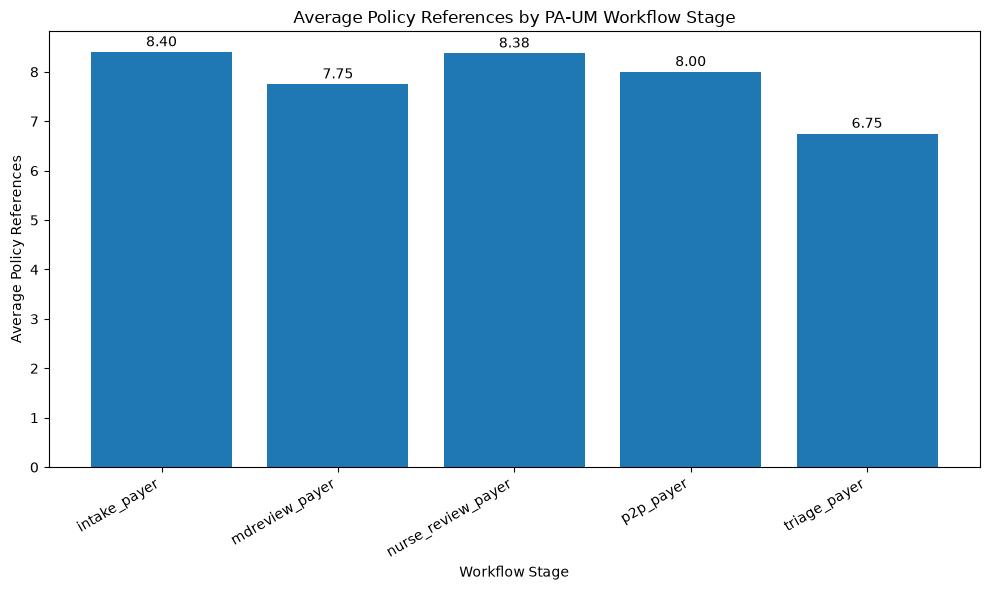

Saved: c:\Users\acharya\Desktop\CHI_Bench\chi-bench\analysis\figures\pa_um_policy_complexity_by_stage.png


In [8]:
import matplotlib.pyplot as plt

stages = list(stage_summary.keys())
avg_policies = [
    stage_summary[stage]["avg_policies"]
    for stage in stages
]

plt.figure(figsize=(10, 6))
bars = plt.bar(stages, avg_policies)

plt.title("Average Policy References by PA-UM Workflow Stage")
plt.xlabel("Workflow Stage")
plt.ylabel("Average Policy References")
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, avg_policies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

FIGURES_DIR = PROJECT_ROOT / "analysis" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

output_path = FIGURES_DIR / "pa_um_policy_complexity_by_stage.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

## Key Observations

- The PA-UM domain contains 25 payer-side prior authorization workflows across five workflow stages.
- Nurse clinical review is the largest stage, representing 32% of the workflows.
- The workflows contain 111 request documents, averaging 4.44 documents per workflow.
- Policy-reference volume ranges from 6 to 10 references per workflow, with an average of 7.96.
- Seventeen of 25 workflows (68%) reference at least 8 policy files, indicating substantial multi-policy documentation requirements.
- MD review workflows have the highest average request-document count at 5.00.
- Intake and nurse review have the highest average policy-reference counts at 8.40 and 8.38 respectively.
- Triage has the lowest average policy-reference count at 6.75.
- Three condition labels occur twice: Headache, Complete rotator cuff tear or rupture of right shoulder, and Rheumatoid arthritis.
- These findings describe benchmark workflow and documentation structure; they should not be interpreted as measures of clinical difficulty or model performance.

## Reproducibility

The analysis uses the PA-UM task metadata extracted from the benchmark's allowed task assets.

### Source data

`analysis/data/pa_um_task_metadata.csv`

### Notebook

`analysis/notebooks/02_pa_um_workflow_analysis.ipynb`

### Visualization

`analysis/figures/pa_um_policy_complexity_by_stage.png`

### Scope

The analysis covers all 25 PA-UM workflow entries.

The analysis uses task metadata, workflow instructions, request-document counts, policy-reference counts, and task configuration metadata. Hidden evaluation artifacts such as solutions, tests, expectations, rubrics, and canonical evaluation records were not used for the analytical conclusions.

## Project Relevance

The PA-UM analysis provides a structured view of payer-side utilization-management workflows within CHI-Bench.

The combination of workflow-stage analysis, request-document volume, and policy-reference complexity demonstrates that the benchmark involves multi-document and multi-policy healthcare authorization workflows rather than simple single-rule classification.

From a healthcare analytics perspective, these workflows involve information retrieval, documentation review, policy matching, clinical workflow routing, and determination-related handoffs.

The analysis can be extended by comparing PA-UM with provider-side prior authorization workflows and care-management workflows while keeping each domain's workflow structure and scope distinct.